<a href="https://colab.research.google.com/github/Payal-mak/Machine-Leaning-Lab/blob/main/Fruit_Ripeness_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EDA & Data Preprocessing**

Using Colab cache for faster access to the 'fruit-ripeness-unripe-ripe-and-rotten' dataset.
Path to dataset files: /kaggle/input/fruit-ripeness-unripe-ripe-and-rotten

--- Dataset Structure ---
Training directory: /kaggle/input/fruit-ripeness-unripe-ripe-and-rotten/fruit_ripeness_dataset/archive (1)/dataset/train
Test directory: /kaggle/input/fruit-ripeness-unripe-ripe-and-rotten/fruit_ripeness_dataset/archive (1)/dataset/test

Number of classes: 9
Classes: ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges', 'unripe apple', 'unripe banana', 'unripe orange']

--- Image Counts and Split ---
Training images: 16217
Test images: 3739
Total images: 19956
Train proportion: 81.26%
Test proportion: 18.74%

--- Checking Image Formats and Sizes ---
Unique sizes: {(162, 40), (162, 104), (374, 402), (272, 382), (196, 170), (656, 420), (440, 356), (566, 462), (162, 122), (644, 390), (336, 402), (414, 404), (474, 418), (162, 106), (486, 456), (394, 446), (6

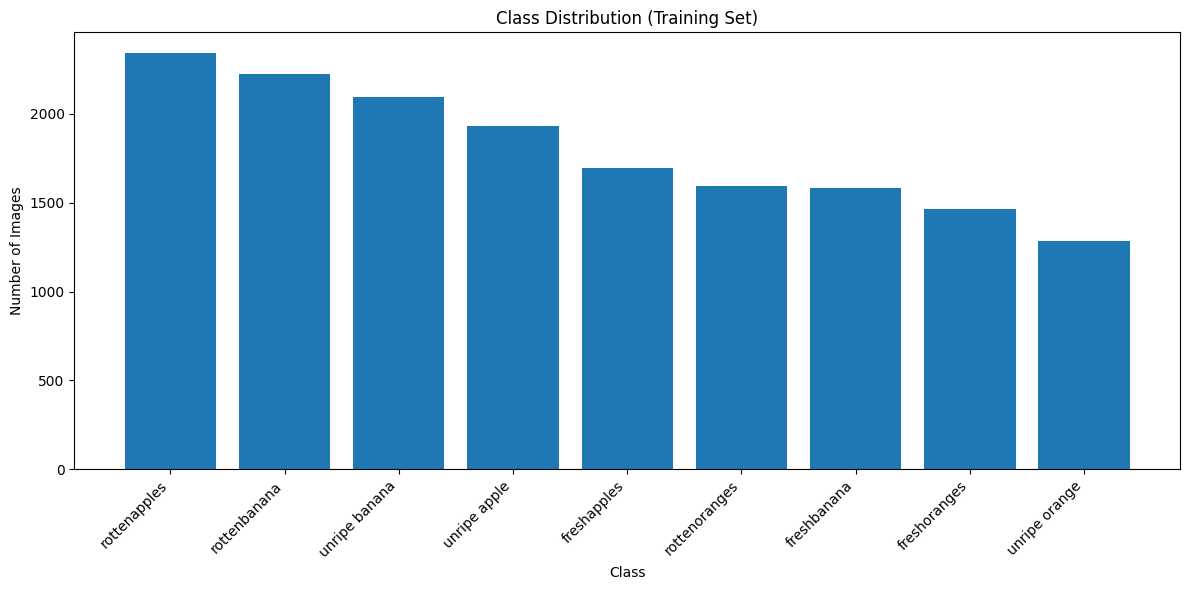


--- Sample Images ---


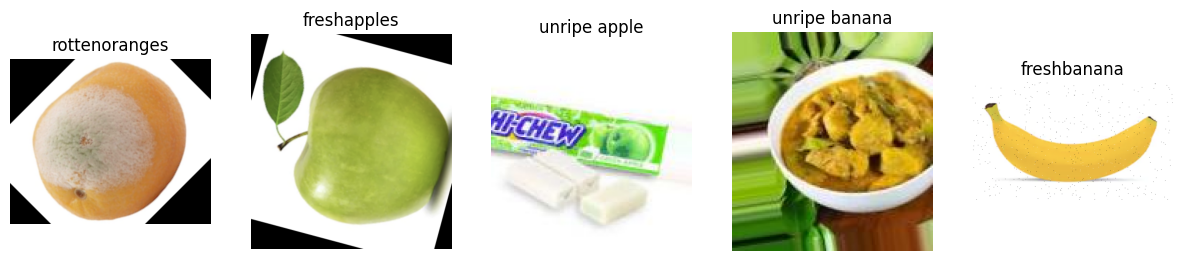


--- Sample Preprocessed Image ---
Shape: (224, 224, 3)
Pixel range: 0.0 to 0.996078431372549

EDA complete. Dataset is clean and ready for CNN training.


In [13]:
# !pip install kagglehub

import kagglehub
import os
import random
import glob
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -------------------------------------------------
# Download Fruit Ripeness Dataset
# -------------------------------------------------
path = kagglehub.dataset_download(
    "leftin/fruit-ripeness-unripe-ripe-and-rotten"
)

print("Path to dataset files:", path)

# -------------------------------------------------
# DATASET STRUCTURE (As per Kaggle)
#
# fruit_ripeness_dataset/
# └── archive (1)/
#     └── dataset/
#         └── dataset/
#             ├── train/
#             └── test/
# -------------------------------------------------
dataset_root = os.path.join(
    path,
    "fruit_ripeness_dataset",
    "archive (1)",
    "dataset"
)

train_dir = os.path.join(dataset_root, "train")
test_dir  = os.path.join(dataset_root, "test")

# Verify paths
assert os.path.exists(train_dir), "Training directory not found!"
assert os.path.exists(test_dir), "Test directory not found!"

print("\n--- Dataset Structure ---")
print("Training directory:", train_dir)
print("Test directory:", test_dir)

# -------------------------------------------------
# Classes
# -------------------------------------------------
classes = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

num_classes = len(classes)

print("\nNumber of classes:", num_classes)
print("Classes:", classes)

# -------------------------------------------------
# Count images
# -------------------------------------------------
def count_images(directory):
    count = 0
    for class_dir in os.listdir(directory):
        class_path = os.path.join(directory, class_dir)
        if os.path.isdir(class_path):
            count += len([
                f for f in os.listdir(class_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ])
    return count

train_count = count_images(train_dir)
test_count  = count_images(test_dir)
total_count = train_count + test_count

print("\n--- Image Counts and Split ---")
print("Training images:", train_count)
print("Test images:", test_count)
print("Total images:", total_count)
print(f"Train proportion: {train_count/total_count*100:.2f}%")
print(f"Test proportion: {test_count/total_count*100:.2f}%")

# -------------------------------------------------
# Check image sizes and formats
# -------------------------------------------------
print("\n--- Checking Image Formats and Sizes ---")

all_train_images = glob.glob(os.path.join(train_dir, "*/*.*"))
sample_images = random.sample(all_train_images, min(200, len(all_train_images)))

sizes = set()
formats = set()

for img_path in sample_images:
    with Image.open(img_path) as img:
        sizes.add(img.size)
        formats.add(img.format)

print("Unique sizes:", sizes)
print("Unique formats:", formats)

if len(sizes) == 1:
    print("All images have the same size.")
else:
    print("Image sizes vary — resizing recommended.")

# -------------------------------------------------
# Class distribution
# -------------------------------------------------
train_class_counts = {
    cls: len(os.listdir(os.path.join(train_dir, cls)))
    for cls in classes
}

df_counts = (
    pd.DataFrame(train_class_counts.items(), columns=["Class", "Count"])
    .sort_values("Count", ascending=False)
)

print("\n--- Class Distribution (Training Set) ---")
print(df_counts)

# -------------------------------------------------
# Plot class distribution
# -------------------------------------------------
plt.figure(figsize=(12, 6))
plt.bar(df_counts["Class"], df_counts["Count"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution (Training Set)")
plt.tight_layout()
plt.show()

# -------------------------------------------------
# Visualize sample images
# -------------------------------------------------
print("\n--- Sample Images ---")

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
sample_classes = random.sample(classes, 5)

for i, cls in enumerate(sample_classes):
    img_file = random.choice(os.listdir(os.path.join(train_dir, cls)))
    img_path = os.path.join(train_dir, cls, img_file)
    img = Image.open(img_path)

    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis("off")

plt.show()

# -------------------------------------------------
# Basic preprocessing example
# -------------------------------------------------
sample_img_path = sample_images[0]
img = Image.open(sample_img_path).resize((224, 224))
img_array = np.array(img) / 255.0

print("\n--- Sample Preprocessed Image ---")
print("Shape:", img_array.shape)
print("Pixel range:", img_array.min(), "to", img_array.max())

print("\nEDA complete. Dataset is clean and ready for CNN training.")

# **Object Feature Extraction**

In [21]:
from google.colab import drive
drive.mount('/content/drive')

# Create a project folder in your Drive
!mkdir -p "/content/drive/MyDrive/Fruit_Ripeness_Project/ml_features"
print("Google Drive mounted! Features will be saved permanently.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted! Features will be saved permanently.


In [22]:
!pip install -q opencv-python scikit-image

In [29]:
!pip install -q kaggle

from google.colab import files
files.upload()  # Upload the downloaded kaggle.json file here

# Setup for legacy kaggle.json
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API setup complete with legacy credentials!")

Saving kaggle.json to kaggle.json
Kaggle API setup complete with legacy credentials!


In [30]:
!kaggle datasets download -d leftin/fruit-ripeness-unripe-ripe-and-rotten

# Unzip
!unzip -q fruit-ripeness-unripe-ripe-and-rotten.zip -d /content/dataset

print("Dataset downloaded and unzipped successfully!")

Dataset URL: https://www.kaggle.com/datasets/leftin/fruit-ripeness-unripe-ripe-and-rotten
License(s): CC-BY-SA-4.0
100% 3.62G/3.63G [00:56<00:00, 127MB/s]
100% 3.63G/3.63G [00:56<00:00, 69.5MB/s]
Dataset downloaded and unzipped successfully!


In [31]:
import os

# Path to the downloaded dataset
dataset_root = "/content/dataset/fruit_ripeness_dataset/archive (1)/dataset/dataset"
train_dir = os.path.join(dataset_root, "train")
test_dir = os.path.join(dataset_root, "test")

print("Train directory exists:", os.path.exists(train_dir))
print("Test directory exists:", os.path.exists(test_dir))

Train directory exists: True
Test directory exists: True


In [32]:
import os
import numpy as np
import cv2
import glob
from sklearn.preprocessing import LabelEncoder
from skimage.feature import local_binary_pattern
import joblib

# Parameters
IMG_SIZE = (224, 224)
HSV_BINS = 32
RGB_BINS = 32
LBP_POINTS = 24
LBP_RADIUS = 3
LBP_BINS = LBP_POINTS + 2  # 26 for uniform LBP

print("Starting feature extraction...")

# Function to extract features from one image
def extract_features(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None
    img = cv2.resize(img, IMG_SIZE)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    features = []

    # 1. HSV color statistics
    for i in range(3):
        chan = img_hsv[:, :, i].ravel()
        features.extend([
            np.mean(chan), np.std(chan),
            np.percentile(chan, 25), np.percentile(chan, 50),
            np.percentile(chan, 75), np.percentile(chan, 90)
        ])

    # 2. HSV histograms (normalized)
    h_hist = cv2.calcHist([img_hsv], [0], None, [HSV_BINS], [0, 180])
    s_hist = cv2.calcHist([img_hsv], [1], None, [HSV_BINS], [0, 256])
    v_hist = cv2.calcHist([img_hsv], [2], None, [HSV_BINS], [0, 256])
    features.extend(cv2.normalize(h_hist, h_hist).flatten())
    features.extend(cv2.normalize(s_hist, s_hist).flatten())
    features.extend(cv2.normalize(v_hist, v_hist).flatten())

    # 3. RGB histograms (normalized)
    r_hist = cv2.calcHist([img], [0], None, [RGB_BINS], [0, 256])
    g_hist = cv2.calcHist([img], [1], None, [RGB_BINS], [0, 256])
    b_hist = cv2.calcHist([img], [2], None, [RGB_BINS], [0, 256])
    features.extend(cv2.normalize(r_hist, r_hist).flatten())
    features.extend(cv2.normalize(g_hist, g_hist).flatten())
    features.extend(cv2.normalize(b_hist, b_hist).flatten())

    # 4. LBP texture
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, LBP_POINTS, LBP_RADIUS, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=LBP_BINS, range=(0, LBP_BINS), density=True)
    features.extend(lbp_hist)

    return np.array(features)

# Get class names
classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
print("Classes found:", classes)

# Collect image paths and labels
def collect_paths_and_labels(directory):
    paths, labels = [], []
    for cls in classes:
        cls_path = os.path.join(directory, cls)
        img_files = glob.glob(os.path.join(cls_path, "*.*"))
        paths.extend(img_files)
        labels.extend([cls] * len(img_files))
    return paths, labels

train_paths, train_labels_str = collect_paths_and_labels(train_dir)
test_paths, test_labels_str = collect_paths_and_labels(test_dir)
print(f"Training images: {len(train_paths)}")
print(f"Test images: {len(test_paths)}")

# Label encoding
le = LabelEncoder()
le.fit(classes)
train_labels = le.transform(train_labels_str)
test_labels = le.transform(test_labels_str)

# Extract features
print("\nExtracting training features...")
train_features = []
for i, path in enumerate(train_paths):
    if i % 500 == 0:
        print(f"  Processed {i}/{len(train_paths)} training images")
    feat = extract_features(path)
    if feat is not None:
        train_features.append(feat)
train_features = np.array(train_features)

print("\nExtracting test features...")
test_features = []
for i, path in enumerate(test_paths):
    if i % 300 == 0:
        print(f"  Processed {i}/{len(test_paths)} test images")
    feat = extract_features(path)
    if feat is not None:
        test_features.append(feat)
test_features = np.array(test_features)

print(f"\nFeature extraction complete!")
print(f"Train features shape: {train_features.shape}")
print(f"Test features shape: {test_features.shape}")
print(f"Features per image: {train_features.shape[1]}")

# Save permanently to Google Drive
output_dir = "/content/drive/MyDrive/Fruit_Ripeness_Project/ml_features"
os.makedirs(output_dir, exist_ok=True)

np.save(os.path.join(output_dir, "train_features.npy"), train_features)
np.save(os.path.join(output_dir, "train_labels.npy"), train_labels)
np.save(os.path.join(output_dir, "test_features.npy"), test_features)
np.save(os.path.join(output_dir, "test_labels.npy"), test_labels)
joblib.dump(le, os.path.join(output_dir, "label_encoder.pkl"))

print("\nAll files saved permanently to your Google Drive!")
print("Path:", output_dir)

Starting feature extraction...
Classes found: ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges', 'unripe apple', 'unripe banana', 'unripe orange']
Training images: 16217
Test images: 3739

Extracting training features...
  Processed 0/16217 training images
  Processed 500/16217 training images
  Processed 1000/16217 training images
  Processed 1500/16217 training images
  Processed 2000/16217 training images
  Processed 2500/16217 training images
  Processed 3000/16217 training images
  Processed 3500/16217 training images
  Processed 4000/16217 training images
  Processed 4500/16217 training images
  Processed 5000/16217 training images
  Processed 5500/16217 training images
  Processed 6000/16217 training images
  Processed 6500/16217 training images
  Processed 7000/16217 training images
  Processed 7500/16217 training images
  Processed 8000/16217 training images
  Processed 8500/16217 training images
  Processed 9000/16217 training imag

Loaded 16217 training samples, 3739 test samples

Starting faster training...
------------------------------------------------------------
Training KNN...
✓ KNN: Accuracy = 0.8679 | F1 = 0.8675


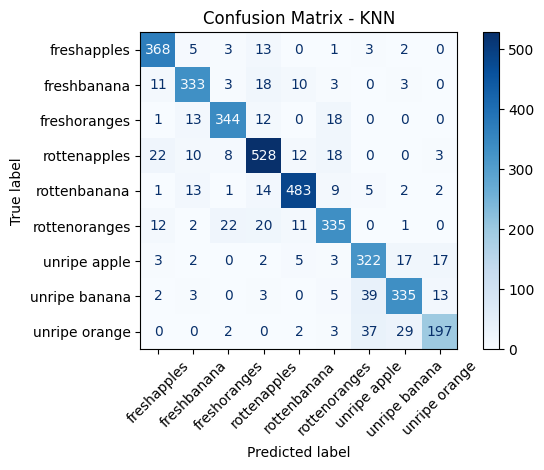

Training SVM (RBF)...
✓ SVM (RBF): Accuracy = 0.5988 | F1 = 0.5884


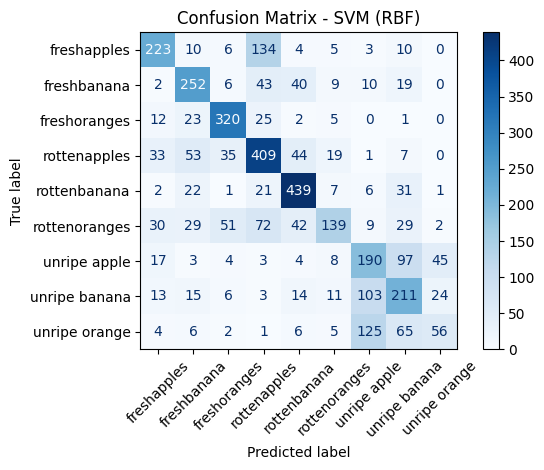

Training SVM (Poly)...
✓ SVM (Poly): Accuracy = 0.6175 | F1 = 0.6060


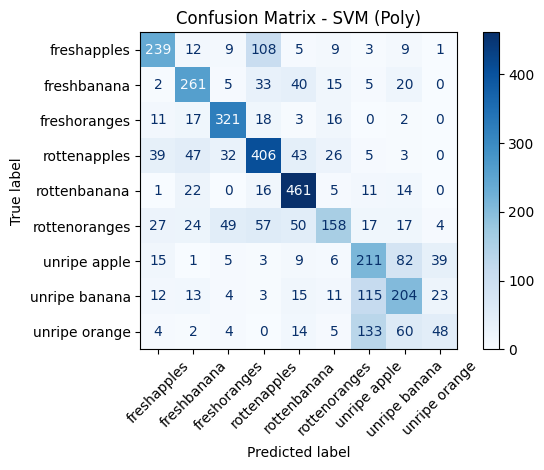

Training Random Forest...
✓ Random Forest: Accuracy = 0.9832 | F1 = 0.9831


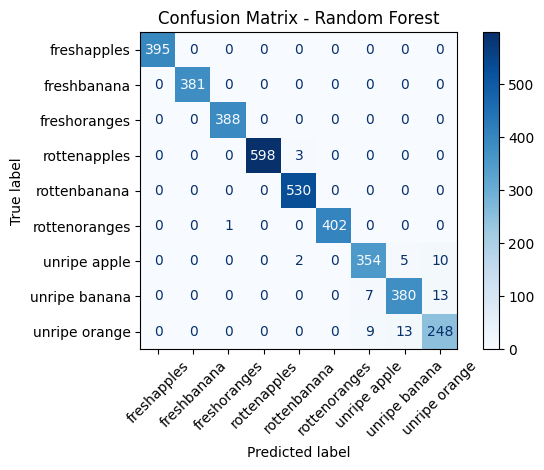

Training Decision Tree...
✓ Decision Tree: Accuracy = 0.9069 | F1 = 0.9066


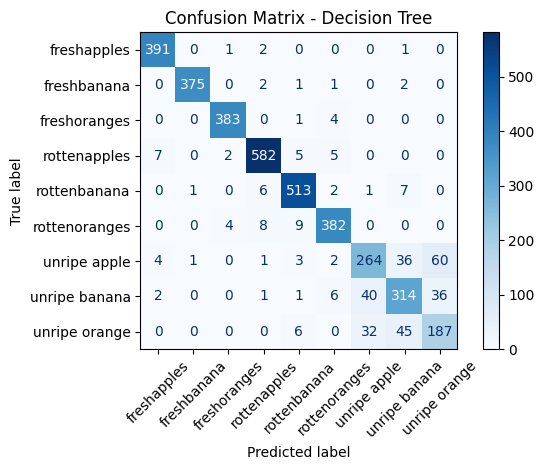

Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [01:34:35] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✓ XGBoost: Accuracy = 0.9909 | F1 = 0.9909


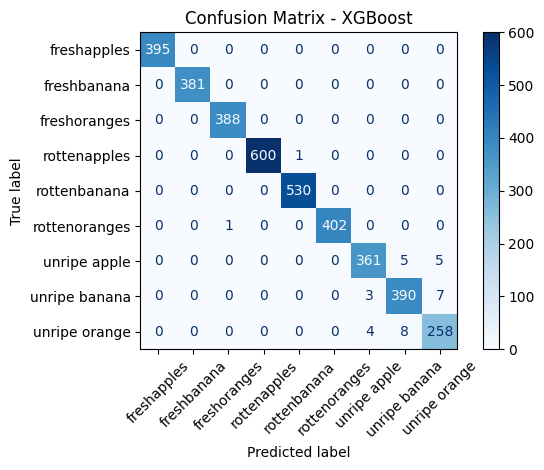

Training LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✓ LightGBM: Accuracy = 0.9914 | F1 = 0.9915


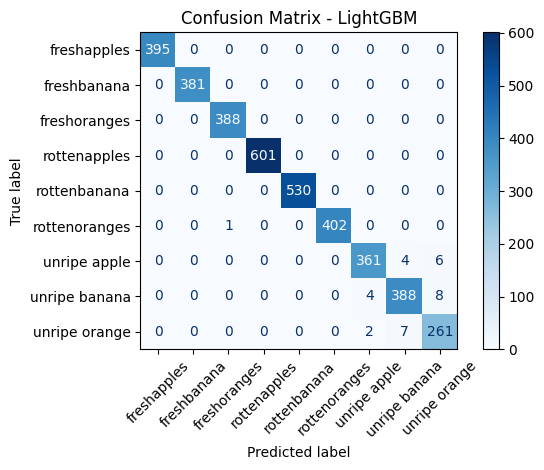

Training AdaBoost...
✓ AdaBoost: Accuracy = 0.6234 | F1 = 0.6240


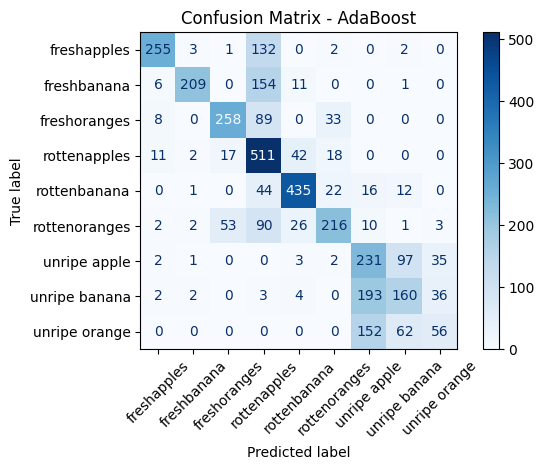

Training Logistic Regression (Softmax)...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


✓ Logistic Regression (Softmax): Accuracy = 0.7109 | F1 = 0.7095


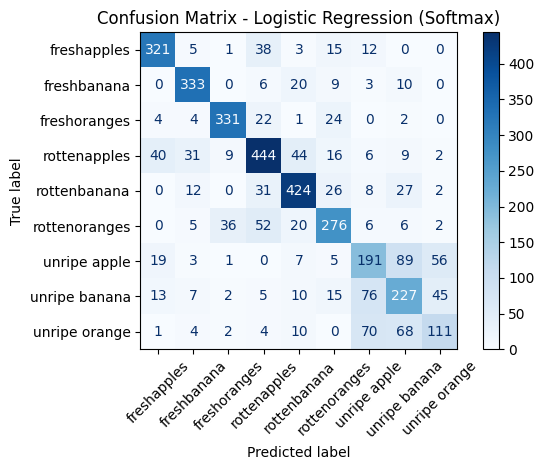


FINAL MODEL COMPARISON (Faster Run)
                           Model  Accuracy  Precision  Recall  F1-Score
1                       LightGBM    0.9914     0.9915  0.9914    0.9915
2                        XGBoost    0.9909     0.9909  0.9909    0.9909
3                  Random Forest    0.9832     0.9832  0.9832    0.9831
4                  Decision Tree    0.9069     0.9066  0.9069    0.9066
5                            KNN    0.8679     0.8684  0.8679    0.8675
6  Logistic Regression (Softmax)    0.7109     0.7094  0.7109    0.7095
7                       AdaBoost    0.6234     0.6707  0.6234    0.6240
8                     SVM (Poly)    0.6175     0.6128  0.6175    0.6060
9                      SVM (RBF)    0.5988     0.6002  0.5988    0.5884

🏆 BEST MODEL: LightGBM with 99.14% Accuracy
Results saved to Drive!


In [34]:
# -------------------------------------------------
# Faster Training Code (Optimized for Colab)
# -------------------------------------------------
import numpy as np
import joblib
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import pandas as pd

# Load features
features_dir = "/content/drive/MyDrive/Fruit_Ripeness_Project/ml_features"

train_features = np.load(os.path.join(features_dir, "train_features.npy"))
train_labels = np.load(os.path.join(features_dir, "train_labels.npy"))
test_features = np.load(os.path.join(features_dir, "test_features.npy"))
test_labels = np.load(os.path.join(features_dir, "test_labels.npy"))
le = joblib.load(os.path.join(features_dir, "label_encoder.pkl"))

class_names = le.classes_
print(f"Loaded {train_features.shape[0]} training samples, {test_features.shape[0]} test samples")

# Faster models list (removed slow GradientBoostingClassifier)
results = []

models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF)": SVC(kernel="rbf", random_state=42, probability=False),  # Faster without probability
    "SVM (Poly)": SVC(kernel="poly", degree=3, random_state=42, probability=False),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),  # Faster with 100 trees
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric="mlogloss", random_state=42, n_jobs=-1),
    "LightGBM": lgb.LGBMClassifier(n_estimators=200, random_state=42, verbose=-1, n_jobs=-1),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Logistic Regression (Softmax)": LogisticRegression(multi_class="multinomial", max_iter=2000, random_state=42, n_jobs=-1)
}

print("\nStarting faster training...\n" + "-"*60)

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(train_features, train_labels)
    pred = model.predict(test_features)

    acc = accuracy_score(test_labels, pred)
    prec = precision_score(test_labels, pred, average="weighted")
    rec = recall_score(test_labels, pred, average="weighted")
    f1 = f1_score(test_labels, pred, average="weighted")

    results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1})

    print(f"✓ {name}: Accuracy = {acc:.4f} | F1 = {f1:.4f}")

    # Confusion Matrix (only show for top performers to save time, or keep all)
    cm = confusion_matrix(test_labels, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

# Final table
df_results = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
df_results.index += 1

print("\n" + "="*100)
print("FINAL MODEL COMPARISON (Faster Run)")
print("="*100)
print(df_results.round(4))

best_model = df_results.iloc[0]["Model"]
best_acc = df_results.iloc[0]["Accuracy"]
print(f"\n🏆 BEST MODEL: {best_model} with {best_acc*100:.2f}% Accuracy")

# Save results
results_path = "/content/drive/MyDrive/Fruit_Ripeness_Project/ml_model_comparison_fast.csv"
df_results.to_csv(results_path)
print(f"Results saved to Drive!")

In [35]:
best_model_name = "LightGBM"
best_model = models[best_model_name]
joblib.dump(best_model, "/content/drive/MyDrive/Fruit_Ripeness_Project/best_model_lightgbm.pkl")
print("Best model saved forever!")

Best model saved forever!


In [37]:
def predict_fruit_ripeness(image_path):
    feat = extract_features(image_path)
    if feat is None:
        return "Error loading image"
    feat = feat.reshape(1, -1)
    pred = best_model.predict(feat)[0]
    prob = best_model.predict_proba(feat)[0]
    class_name = le.inverse_transform([pred])[0]
    confidence = prob[pred] * 100
    return f"{class_name} ({confidence:.1f}%)"

# Test it live
print(predict_fruit_ripeness("/content/apple1.webp"))
# Try your own photos too!

unripe apple (99.1%)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
